## Let's run intron clustering to annotate alternative splicing events given observed junctions in our cells 

In [1]:
!hostname

pe2cc3-042.c.nygenome.org


In [2]:
import os
import pandas as pd 
from sklearn.decomposition import TruncatedSVD
import anndata as ad
from scipy.sparse import coo_matrix
from datetime import datetime

# turn this into AnnData object 
import anndata as ad
from scipy.sparse import csr_matrix
import numpy as np
import torch 
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc

from scipy.spatial.distance import cdist

import numpy as np

import sys
import os
import json
import numpy as np
import torch
import anndata as ad
from importlib import reload
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import pyro 
import umap.umap_ as umap
import matplotlib.patches as mpatches
import scipy.sparse
import datetime
import sys
import random

sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/visualization')
# from visualize_ATSE import visualize_local_events

# Import custom modules
sys.path.append('/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor')

import factor_model
reload(factor_model)

import waypoints_prep_input as wayp
reload(wayp)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

float_type = {"device": device, "dtype": torch.float}
if device == torch.device('cuda'):
    torch.set_default_tensor_type('torch.cuda.FloatTensor')

!hostname

2.3.0+cu121
12.1
2.3.0+cu121
12.1
Using device: cpu
pe2cc3-042.c.nygenome.org


### Specify if we want to prep brain only file or ALL tissue file


In [3]:
gtf_annot=True

### Load merged anndata file containing all cells. NOTE: The input file going in to this is coming from the script: '/gpfs/commons/home/kisaev/Leaflet-analysis/tabula_sapien/Leaflet/Code/01_Anndata_generate.py' and will depend on whether a GTF file was using for ATSE mapping or not! 

In [4]:
input_file="/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs/ATSE_Anndata_with_GTF_Object_20250108_143401.h5ad"
adata_full = ad.read_h5ad(input_file)
splice_adata = adata_full.copy()
splice_adata.obs.reset_index(drop=True, inplace=True)
splice_adata.obs["cell_id_index"] = splice_adata.obs.index 

# Note: this ATSE file was also generated through the script mentioned above
ATSE_file="/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs/tabula-sapien_with_annotations_50_500000_20_20250108_single_cell.gz"
atses = pd.read_csv(ATSE_file, sep="}")

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Load in gene expression matrix for smart-seq2 data and align cell IDs 

In [5]:
# Load the expression data (.h5ad file)
exp_file = "/gpfs/commons/datasets/controlled/BRAIN_NeMO/lein-human-cortex/GeneExpression/TabulaSapien_AllenBrain_combined_nonneuron_adata_2025-01-08.h5ad"
adata = sc.read_h5ad(exp_file)
# subset adata to just adata where obs.source == "tabula_sapiens"
adata = adata[adata.obs.source == "tabula_sapiens"].copy()
adata.obs["cell_id"] = adata.obs.index

##### Clean up Cell IDs in the splicing Anndata object so can merge them with the IDs in the gene expression object

In [6]:
splice_adata.obs["clean_cell_id"] = splice_adata.obs["bam_file_name"].str.replace(
    r"\.homo\.gencode\.v30\.ERCC\.chrM$", "", regex=True
)

adata.obs["clean_cell_id"] = adata.obs["cell_id"].str.replace(r'-\d+$', '', regex=True)

### Make Cell IDs comperable between gene expression (downloaded from website) and splicing (made by us) Anndata objects 

In [7]:
# Make cell IDs comperable 
splice_adata = splice_adata[splice_adata.obs["clean_cell_id"].isin(adata.obs["clean_cell_id"])]
adata = adata[adata.obs["clean_cell_id"].isin(splice_adata.obs["clean_cell_id"])]
adata.obs.reset_index(drop=True, inplace=True)

# Rename the existing 'cell_id_index' to 'old_cell_id_index'
splice_adata.obs.rename(columns={'cell_id_index': 'old_cell_id_index'}, inplace=True)
splice_adata.obs.reset_index(inplace=True, drop=True)

# Create a new 'cell_id_index' based on the current index
splice_adata.obs['cell_id_index'] = splice_adata.obs.index
splice_adata.obs_names = splice_adata.obs["clean_cell_id"]
adata.obs_names = adata.obs["clean_cell_id"]

print(adata.shape)
print(splice_adata.shape)

/scratch/ipykernel_22608/2219573618.py:11: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  splice_adata.obs['cell_id_index'] = splice_adata.obs.index
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


(23050, 28230)
(23050, 31544)


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Clean up tissue and cell_type grouping names

In [8]:
# Dictionary to consolidate duplicates
subtissue_corrections = {
    'T cells': 'T-cells',
    'ENDOMUCIN': 'Endomucin',
    'forelimb and hindlimb': 'ForelimbandHindlimb',
    'Liver non-hepato/SCs_st': 'Liver non-hepato/SCs',
    'Skin Anagen': 'Anagen'
}

cell_type_groupings = {
    
    # Basal cells
    'basal cell of epidermis': 'BASAL CELL',
    'basal cell': 'BASAL CELL',

    # Endothelial cells
    'endothelial cell': 'ENDOTHELIAL CELL',
    'endothelial cell of coronary artery': 'ENDOTHELIAL CELL',
    'endothelial cell of hepatic sinusoid': 'ENDOTHELIAL CELL',
    'aortic endothelial cell': 'ENDOTHELIAL CELL',
    'vein endothelial cell': 'ENDOTHELIAL CELL',
    'endothelial cell of lymphatic vessel': 'ENDOTHELIAL CELL',

    # T cells
    'T cell': 'T CELL',
    'CD4-positive, alpha-beta T cell': 'T CELL',
    'CD8-positive, alpha-beta T cell': 'T CELL',
    'regulatory T cell': 'T CELL',
    'mature NK T cell': 'T CELL',
    'mature alpha-beta T cell': 'T CELL',
    
    # B cells
    'B cell': 'B CELL',
    'immature B cell': 'B CELL',
    'naive B cell': 'B CELL',
    'precursor B cell': 'B CELL',
    'early pro-B cell': 'B CELL',
    'late pro-B cell': 'B CELL',
    'plasma cell': 'B CELL',

    # Fibroblasts
    'fibroblast': 'FIBROBLAST',
    'fibroblast of cardiac tissue': 'FIBROBLAST',
    'fibroblast of lung': 'FIBROBLAST',
    'pulmonary interstitial fibroblast': 'FIBROBLAST',
    'kidney interstitial fibroblast': 'FIBROBLAST',
    'fibrocyte': 'FIBROBLAST',

    # Macrophages 
    'macrophage': 'MACROPHAGE',
    'Kupffer cell': 'MACROPHAGE', # macrophages in the liver
    'lung macrophage': 'MACROPHAGE',

    # Monocytes
    'monocyte': 'MONOCYTE',
    'classical monocyte': 'MONOCYTE',
    'non-classical monocyte': 'MONOCYTE',
    'intermediate monocyte': 'MONOCYTE',

    # General Immune Cells
    'granulocyte': 'GRANULOCYTE',
    'basophil': 'GRANULOCYTE', 
    'granulocyte monocyte progenitor cell': 'GRANULOCYTE',

    'leukocyte': 'GENERAL IMMUNE CELL',
    'professional antigen presenting cell': 'ANTIGEN PRESENTING CELL',

    'lymphocyte': 'LYMPHOID IMMUNE CELL',
    'NK cell': 'LYMPHOID IMMUNE CELL',

    'myeloid cell': 'MYELOID IMMUNE CELL',
    'myeloid leukocyte': 'MYELOID IMMUNE CELL',
    'granulocytopoietic cell': 'MYELOID IMMUNE CELL',
    'promonocyte': 'MYELOID IMMUNE CELL',

    'thymocyte': 'THYMOCYTE',
    'DN4 thymocyte': 'THYMOCYTE',

    # Neutrophils
    'neutrophil': 'NEUTROPHIL',

    # Dendritic Cells
    'dendritic cell': 'DENDRITIC CELL',
    'plasmacytoid dendritic cell': 'DENDRITIC CELL',
    'myeloid dendritic cell': 'DENDRITIC CELL',

    # Microglia (Brain Immune Cells)
    'microglial cell': 'MICROGLIA',
    
    # Pancreatic cells
    'pancreatic A cell': 'PANCREATIC CELL',
    'pancreatic B cell': 'PANCREATIC CELL',
    'pancreatic D cell': 'PANCREATIC CELL',
    'pancreatic acinar cell': 'PANCREATIC CELL',
    'pancreatic PP cell': 'PANCREATIC CELL',
    'pancreatic ductal cell': 'PANCREATIC CELL',
    'pancreatic stellate cell': 'PANCREATIC CELL',
    
    # Smooth muscle cells
    'smooth muscle cell': 'SMOOTH MUSCLE CELL',
    'bronchial smooth muscle cell': 'SMOOTH MUSCLE CELL',
    'smooth muscle cell of the pulmonary artery': 'SMOOTH MUSCLE CELL',
    'smooth muscle cell of trachea': 'SMOOTH MUSCLE CELL',
    
    # Epithelial cells (includes luminal epithelial cell of mammary gland)
    'epithelial cell': 'EPITHELIAL CELL',
    'epidermal cell': 'EPITHELIAL CELL',
    'epithelial cell of large intestine': 'EPITHELIAL CELL',
    'enterocyte of epithelium of large intestine': 'EPITHELIAL CELL',
    'epithelial cell of proximal tubule': 'EPITHELIAL CELL',
    'epithelial cell of thymus': 'EPITHELIAL CELL',
    'bladder urothelial cell': 'EPITHELIAL CELL',
    'basal epithelial cell of tracheobronchial tree': 'EPITHELIAL CELL',
    'luminal epithelial cell of mammary gland': 'EPITHELIAL CELL',

    # Neurons
    'neuron': 'NEURON',
    'medium spiny neuron': 'NEURON',
    'interneuron': 'NEURON',
    'neuronal stem cell': 'NEURON',

    # Glial Cells (excluding microglia)
    'oligodendrocyte': 'GLIAL CELL',
    'oligodendrocyte precursor cell': 'GLIAL CELL',
    'astrocyte': 'GLIAL CELL',
    'Bergmann glial cell': 'GLIAL CELL',
    'ependymal cell': 'GLIAL CELL',

    # Stem cells
    'mesenchymal stem cell': 'STEM CELL',
    'mesenchymal stem cell of adipose': 'STEM CELL',
    'hematopoietic stem cell': 'STEM CELL',
    'neuronal stem cell': 'STEM CELL',
    'intestinal crypt stem cell': 'STEM CELL',
    'keratinocyte stem cell': 'STEM CELL',
    'lymphoid progenitor cell': 'STEM CELL',
    'proerythroblast': 'STEM CELL',
    'megakaryocyte-erythroid progenitor cell': 'STEM CELL',

    # Other specialized cells
    'ventricular myocyte': 'CARDIAC MUSCLE CELL',
    'atrial myocyte': 'CARDIAC MUSCLE CELL',
    'skeletal muscle satellite cell': 'SKELETAL MUSCLE CELL',
    'kidney collecting duct principal cell': 'KIDNEY CELL',
    'kidney collecting duct epithelial cell': 'KIDNEY CELL',
    'kidney interstitial fibroblast': 'FIBROBLAST',
    'mesangial cell': 'KIDNEY CELL',
    'type I pneumocyte': 'LUNG CELL',
    'type II pneumocyte': 'LUNG CELL',
    'club cell of bronchiole': 'LUNG CELL',
    'lung neuroendocrine cell': 'LUNG CELL',
    'ciliated columnar cell of tracheobronchial tree': 'LUNG CELL',
    'respiratory basal cell': 'LUNG CELL',
    'Brush cell of epithelium proper of large intestine': 'INTESTINAL CELL',
    'large intestine goblet cell': 'INTESTINAL CELL',
    'enteroendocrine cell': 'INTESTINAL CELL',
    'stromal cell': 'STROMAL CELL',
    'pericyte cell': 'PERICYTE',
    'brain pericyte': 'PERICYTE',
    'adventitial cell': 'STROMAL CELL',
    'keratinocyte': 'KERATINOCYTE',
    'bulge keratinocyte': 'KERATINOCYTE',
    'hepatocyte': 'HEPATOCYTE',
    'bladder cell': 'BLADDER CELL',
    'secretory cell': 'SECRETORY CELL',
    'endocardial cell': 'ENDOCARDIAL CELL',
    'valve cell': 'VALVE CELL',
    'chondrocyte': 'STROMAL CELL',
    'fenestrated cell': 'FENESTRATED CELL',
    'neuroepithelial cell': 'NEUROEPITHELIAL CELL',
    'kidney loop of Henle ascending limb epithelial cell': 'KIDNEY CELL',
    'mucus secreting cell': 'SECRETORY CELL'
}

In [9]:
# Add new cell type groupings 
splice_adata.obs['cell_ontology_class'] = splice_adata.obs['cell_ontology_class'].astype(str)
splice_adata.obs['cell_type_grouped'] = splice_adata.obs['cell_ontology_class'].replace(cell_type_groupings)
splice_adata.obs['cell_type_grouped'] = splice_adata.obs['cell_type_grouped'].fillna(adata.obs['cell_ontology_class'])
splice_adata.obs['cell_type_grouped'].value_counts()

cell_type_grouped
MONOCYTE                                 1427
STEM CELL                                1354
MACROPHAGE                               1354
cd8-positive, alpha-beta t cell          1102
memory b cell                            1086
                                         ... 
ionocyte                                    1
pancreatic beta cell                        1
retinal bipolar neuron                      1
radial glial cell                           1
retinal blood vessel endothelial cell       1
Name: count, Length: 113, dtype: int64

### Subset to just cell types with more than 50 cells in them

In [10]:
# Step 1: Count the number of cells per cell type in 'cell_ontology_class'
cell_type_counts = splice_adata.obs['cell_type_grouped'].value_counts()

# Step 2: Filter for cell types with more than 50 cells
cell_types_to_keep = cell_type_counts[cell_type_counts > 50].index

# Step 3: Subset the AnnData object to only include these cell types
splice_adata = splice_adata[splice_adata.obs['cell_type_grouped'].isin(cell_types_to_keep)]

# Print the subsetted cell types and their counts
print(splice_adata.obs['cell_type_grouped'].value_counts())

cell_type_grouped
MONOCYTE                                                1427
MACROPHAGE                                              1354
STEM CELL                                               1354
cd8-positive, alpha-beta t cell                         1102
memory b cell                                           1086
BASAL CELL                                              1060
FIBROBLAST                                               974
cd4-positive, alpha-beta t cell                          944
ENDOTHELIAL CELL                                         783
EPITHELIAL CELL                                          724
B CELL                                                   722
t cell                                                   715
mature enterocyte                                        680
b cell                                                   634
endothelial cell of vascular tree                        600
nk cell                                                  600
innate

In [11]:
# Filter the gene expression object to just these cells and add the useful columns 
adata_reordered = adata[splice_adata.obs_names]
splice_adata.obs.rename_axis('cell_id_for_index', inplace=True)
adata_reordered.obs.rename_axis('cell_id_for_index', inplace=True)

### Sanity check to ensure cells ordered in the same way between the two objects!

In [12]:
(adata_reordered.obs_names == splice_adata.obs_names).all()

True

In [13]:
adata_reordered.var["gene_name"] = adata_reordered.var["gene_symbol-0"]

/scratch/ipykernel_22608/2750319624.py:1: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata_reordered.var["gene_name"] = adata_reordered.var["gene_symbol-0"]


### Merge ATSE gene information if it's there to splice_adata object!

In [14]:
if gtf_annot:
    splice_adata.var = splice_adata.var.merge(atses[["gene_id", "gene_name", "junction_id"]], on=["gene_id", "junction_id"])
else:
    splice_adata.var = splice_adata.var.merge(atses[["junction_id"]], on=["junction_id"])    

### Obtain sparse junction usage ratios! (First filter to keep only junctions with reasonable coverage...)

In [15]:
# Extract junction counts and cluster counts as sparse matrices
junction_counts = splice_adata.layers["cell_by_junction_matrix"] 
junction_counts = junction_counts.tocoo()

cluster_counts = splice_adata.layers["cell_by_cluster_matrix"]    
cluster_counts = cluster_counts.tocoo()

In [16]:
# Filter junctions, ensuring they have reasonable coverage 
junc_norm_sum = wayp.sparse_sum(junction_counts, 0) / junction_counts.shape[0]
min_junc_mean = 0.005 # default 
to_keep = junc_norm_sum > min_junc_mean
juncs_filter = splice_adata.var[to_keep]

print(f"Number of junctions in matrix before filtering: {len(junc_norm_sum)}")
print(f"Number of junctions after filtering {len(junc_norm_sum[to_keep])}")

Number of junctions in matrix before filtering: 31544
Number of junctions after filtering 30883


### Ensure we are only keeping ATSEs for downstream analysis with at least two junctions post filtering 

In [17]:
cluster_junction_counts = juncs_filter.groupby("Cluster")["junction_id"].count()
clusters_to_keep = cluster_junction_counts[cluster_junction_counts >= 2].index
juncs_filter_final = juncs_filter[juncs_filter["Cluster"].isin(clusters_to_keep)]

splice_adata.var['old_index'] = splice_adata.var.index
splice_adata = splice_adata[:, juncs_filter_final.index]
splice_adata.var = splice_adata.var.reset_index(drop=True)
splice_adata.var["junction_id_index"] = splice_adata.var.index

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Now make sure there are no cells wtih zero counts across the board!

In [18]:
# Access the sparse matrix with junction counts (assumed to be in layers['cell_by_junction_matrix'])
junction_matrix = splice_adata.layers['cell_by_junction_matrix']

# Check if the matrix is sparse (it should be sparse to avoid conversion to dense)
if isinstance(junction_matrix, csr_matrix):
    # Sum across each row (axis=1) and check if the sum is zero (meaning the row is all zeros)
    non_zero_cells = junction_matrix.getnnz(axis=1) > 0
else:
    raise ValueError("The matrix is not sparse!")

print(len(non_zero_cells))

# Filter the AnnData object to remove cells with all zero counts
splice_adata = splice_adata[non_zero_cells, :]

22179


### Save junction/ATSEs in SpliceGirls format

In [19]:
juncs_clusts = splice_adata.var[["junction_id", "Cluster"]]

## Apply the transformation and use .loc to set the new column to avoid the warning
juncs_clusts.loc[:, 'formatted'] = juncs_clusts.apply(wayp.transform_row, axis=1)
## Print the resulting formatted values
## juncs_clusts[['formatted']].to_csv("formatted_junctions_splice_girls_input.tsv", sep="\t", index=False, header=False)

/scratch/ipykernel_22608/164303478.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  juncs_clusts.loc[:, 'formatted'] = juncs_clusts.apply(wayp.transform_row, axis=1)


#### Get sparse PCA, UMAP and Diffusion Map!

In [20]:
# Extract junction counts and cluster counts as sparse matrices 
junction_counts = splice_adata.layers["cell_by_junction_matrix"] 
cluster_counts = splice_adata.layers["cell_by_cluster_matrix"]    

# Ensure the matrices are in COO format for easier element-wise operations
junction_counts = junction_counts.tocoo()
cluster_counts = cluster_counts.tocoo()

In [21]:
# Get sparse centered PSI values 
splice_adata.layers["junc_ratio"] = wayp.calculate_centered_psi(junction_counts, cluster_counts)

# Step 1: Perform PCA using sparse data
n_components = 40  # Number of components to keep

n_iter = 5  # Increasing the number of iterations for better convergence
svd = TruncatedSVD(n_components=n_components, n_iter=n_iter, random_state=42)

# Fit and transform the junction ratio data (this gives U)
U = svd.fit_transform(splice_adata.layers["junc_ratio"])

# Get the singular values (S)
S = svd.singular_values_

# Multiply U by S to get U * S
# Need to scale U by the singular values S (broadcasted across columns)
U_by_S = U * S  # This scales each component in U by the corresponding singular value in S

# Store the PCA results (U * S) in the 'X_pca' field of .obsm (multi-dimensional)
splice_adata.obsm['X_pca'] = U_by_S

# Optionally, store explained variance ratio for future reference
splice_adata.uns['pca_explained_variance_ratio'] = svd.explained_variance_ratio_

/scratch/ipykernel_22608/450472730.py:2: ImplicitModificationWarning: Setting element `.layers['junc_ratio']` of view, initializing view as actual.
  splice_adata.layers["junc_ratio"] = wayp.calculate_centered_psi(junction_counts, cluster_counts)
/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [22]:
pca_result = U_by_S

# Step 2: Compute UMAP on the PCA-reduced data
sc.pp.neighbors(splice_adata, use_rep='X_pca')

# Step 3. Calculate UMAP 
sc.tl.umap(splice_adata)

# Step 4. Calculate the diffusion map
sc.tl.diffmap(splice_adata)

# The diffusion components are now stored in adata.obsm['X_diffmap']
diffmap_components = splice_adata.obsm['X_diffmap']
pca_components = splice_adata.obsm["X_pca"]

# Step 5. Run tSNE 
sc.tl.tsne(splice_adata)
tsne_components = splice_adata.obsm["X_tsne"]

### Identify cell waypoints using splicing based PCs!

In [23]:
# Define possible number of waypoints to learn
n_waypoints_learn = [30, 50, 100]

# Placeholder to store waypoints and metacell dictionaries for each n_waypoints
waypoints_dict = {}
metacell_dicts = {}

# Parameters
num_components = 10  # Number of diffusion map components to consider
metacell_size = 50    # Number of nearest cells to assign to each waypoint

# Loop over different n_waypoints to generate waypoints and metacell assignments
for n_waypoints in n_waypoints_learn:

    print(f"Finding {n_waypoints} waypoints from the diffusion components!")
    random_seed = np.random.randint(0, 10000 + 1)  # Generate random seed
    
    # Max-min sampling to identify waypoints
    waypoints = wayp.max_min_sampling(pca_components, n_waypoints, num_components=num_components, seed=random_seed)
    
    # Store waypoints for this particular number of waypoints
    waypoints_dict[n_waypoints] = waypoints

    # Assign nearest cells to each waypoint (metacells)
    metacell_dict = wayp.assign_nearest_cells(waypoints, pca_components, num_nearest=metacell_size)
    
    # Store the metacell dictionary for this number of waypoints
    metacell_dicts[n_waypoints] = metacell_dict

Finding 30 waypoints from the diffusion components!
Finding 50 waypoints from the diffusion components!
Finding 100 waypoints from the diffusion components!


#### Try looking at waypoints just using PC space...

In [24]:
len(splice_adata.var.gene_name.unique())

7422

In [25]:
splice_adata.obs

,bam_file_name,organ_tissue,method,donor,anatomical_information,n_counts_UMIs,n_genes,cell_ontology_class,free_annotation,compartment,gender,donor_id,old_cell_id_index,clean_cell_id,cell_id_index,cell_type_grouped
cell_id_for_index,,,,,,,,,,,,,,,,
TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneLinNeg_A13_L004,TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneL...,Skin,smartseq2,TSP10,abdomen,77711.0,2297.0,macrophage,macrophage,immune,male,Pilot10,0,TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneL...,0,MACROPHAGE
TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneLinNeg_A14_L004,TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneL...,Skin,smartseq2,TSP10,abdomen,499895.0,2727.0,macrophage,macrophage,immune,male,Pilot10,1,TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneL...,1,MACROPHAGE
TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneLinNeg_A17_L004,TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneL...,Skin,smartseq2,TSP10,abdomen,131433.0,2314.0,macrophage,macrophage,immune,male,Pilot10,2,TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneL...,2,MACROPHAGE
TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneLinNeg_A20_L004,TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneL...,Skin,smartseq2,TSP10,abdomen,108378.0,2314.0,macrophage,macrophage,immune,male,Pilot10,3,TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneL...,3,MACROPHAGE
TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneLinNeg_B6_L004,TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneL...,Skin,smartseq2,TSP10,abdomen,750143.0,2569.0,macrophage,macrophage,immune,male,Pilot10,5,TSP10_Skin_abdomen_SS2_B134173_B133831_ImmuneL...,5,MACROPHAGE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TSP3_Eye_lacrimalgland_SS2_B114698_B133920_Endothelial_L23_L002,TSP3_Eye_lacrimalgland_SS2_B114698_B133920_End...,Eye,smartseq2,TSP3,lacrimalgland,17519.0,271.0,lacrimal gland functional unit cell,lacrimal gland functional unit cells,stromal,female,Pilot3,26113,TSP3_Eye_lacrimalgland_SS2_B114698_B133920_End...,23041,lacrimal gland functional unit cell
TSP3_Eye_noCornea_SS2_B114664_B133905_Immune_B7_S31,TSP3_Eye_noCornea_SS2_B114664_B133905_Immune_B...,Eye,smartseq2,TSP3,noCornea,606352.0,2055.0,t cell,t cells,immune,female,Pilot3,26114,TSP3_Eye_noCornea_SS2_B114664_B133905_Immune_B...,23042,t cell
TSP3_Eye_noCornea_SS2_B114664_B133905_Immune_G10_S154,TSP3_Eye_noCornea_SS2_B114664_B133905_Immune_G...,Eye,smartseq2,TSP3,noCornea,747684.0,3294.0,macrophage,macrophages,immune,female,Pilot3,26116,TSP3_Eye_noCornea_SS2_B114664_B133905_Immune_G...,23044,MACROPHAGE


... storing 'cell_ontology_class' as categorical
... storing 'cell_type_grouped' as categorical
... storing 'gene_id' as categorical
... storing 'gene_name' as categorical
/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/waypoints_prep_input.py:355: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


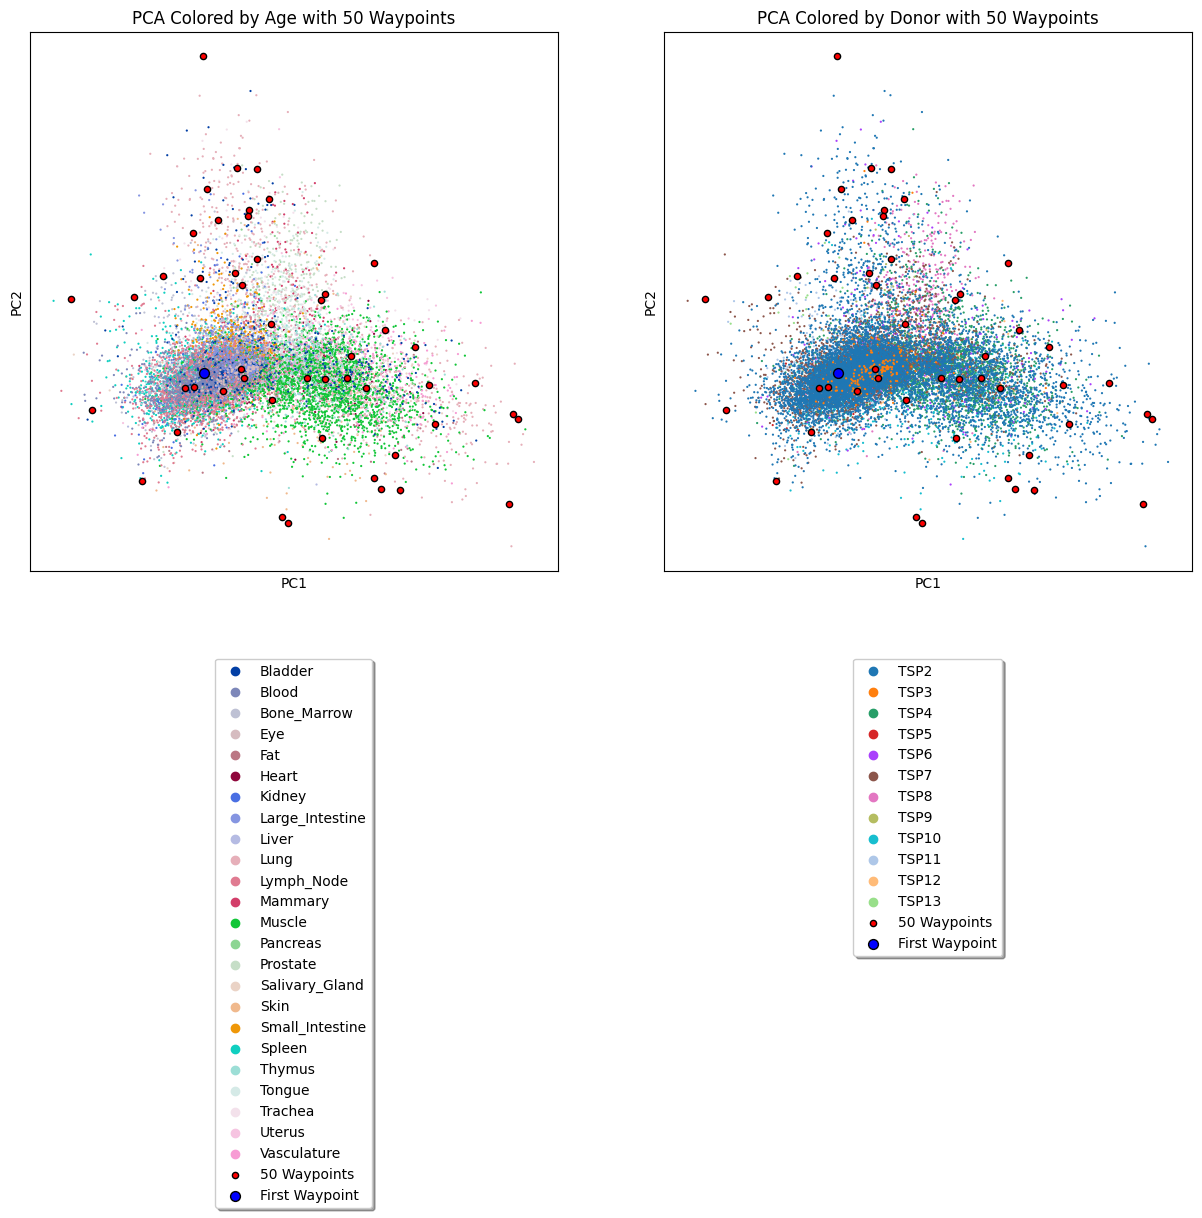

In [26]:
wayp.plot_PCA_with_waypoints(splice_adata, waypoints_dict, color_by="organ_tissue", n_waypoints=50, waypoint_color='red', first_waypoint_color='blue', second_color="donor", size=10)
# wayp.plot_tSNE_with_waypoints(splice_adata, waypoints_dict, color_by="organ_tissue", n_waypoints=50, waypoint_color='red', first_waypoint_color='blue', second_color="donor", size=10)

/gpfs/commons/home/kisaev/Leaflet-private/src/beta-dirichlet-factor/waypoints_prep_input.py:261: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


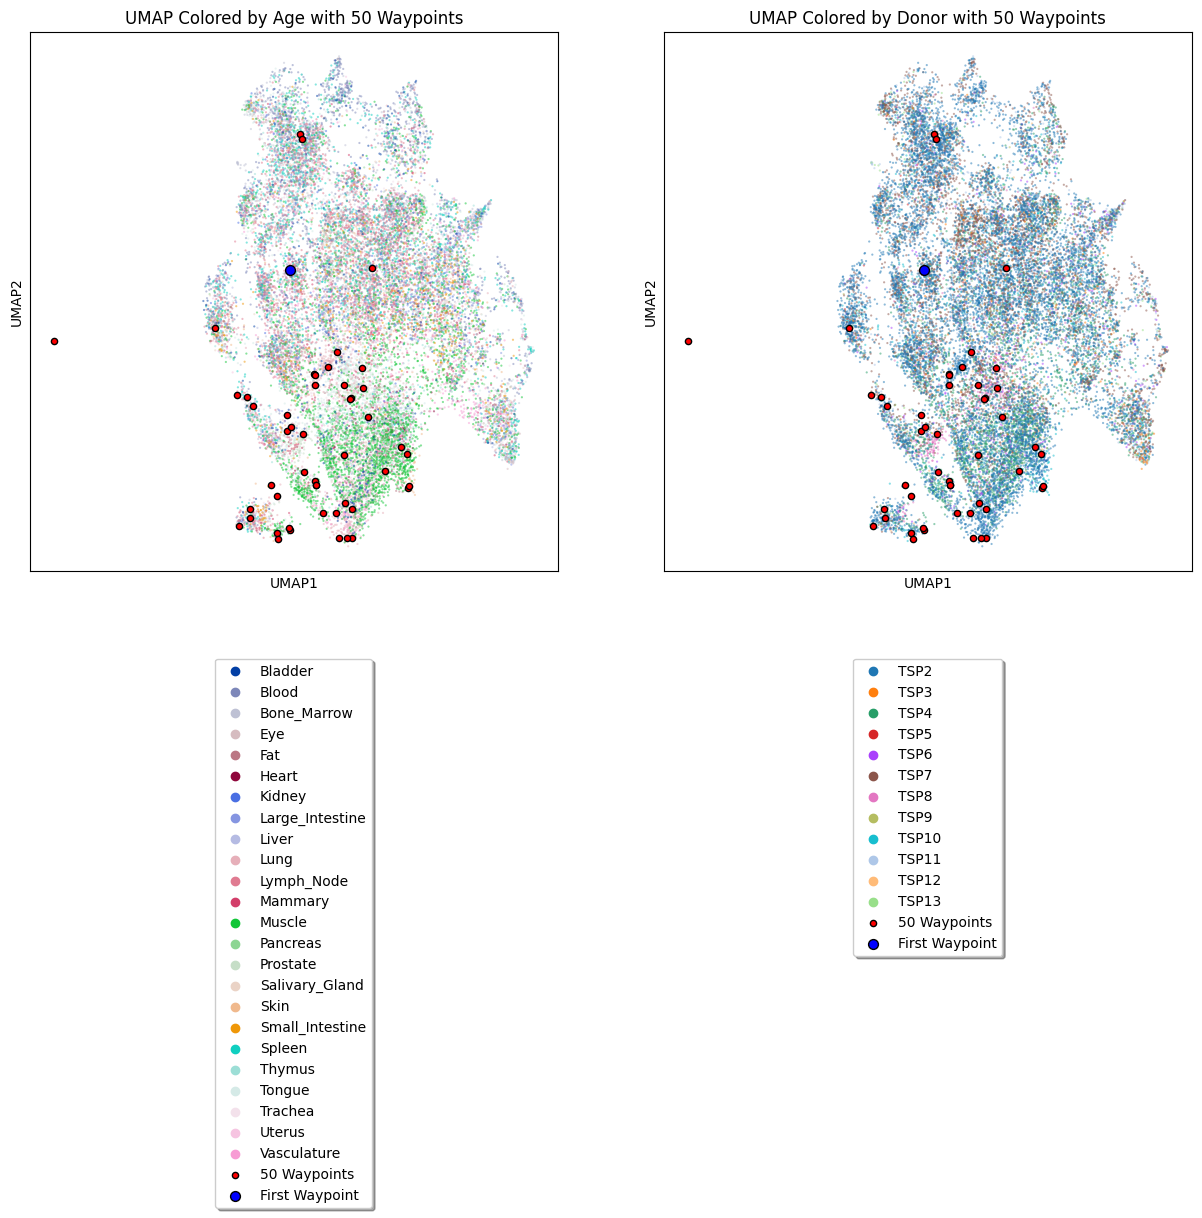

In [27]:
wayp.plot_UMAP_with_waypoints(splice_adata, waypoints_dict, color_by="organ_tissue", n_waypoints=50, waypoint_color='red', first_waypoint_color='blue', second_color="donor", size=10)

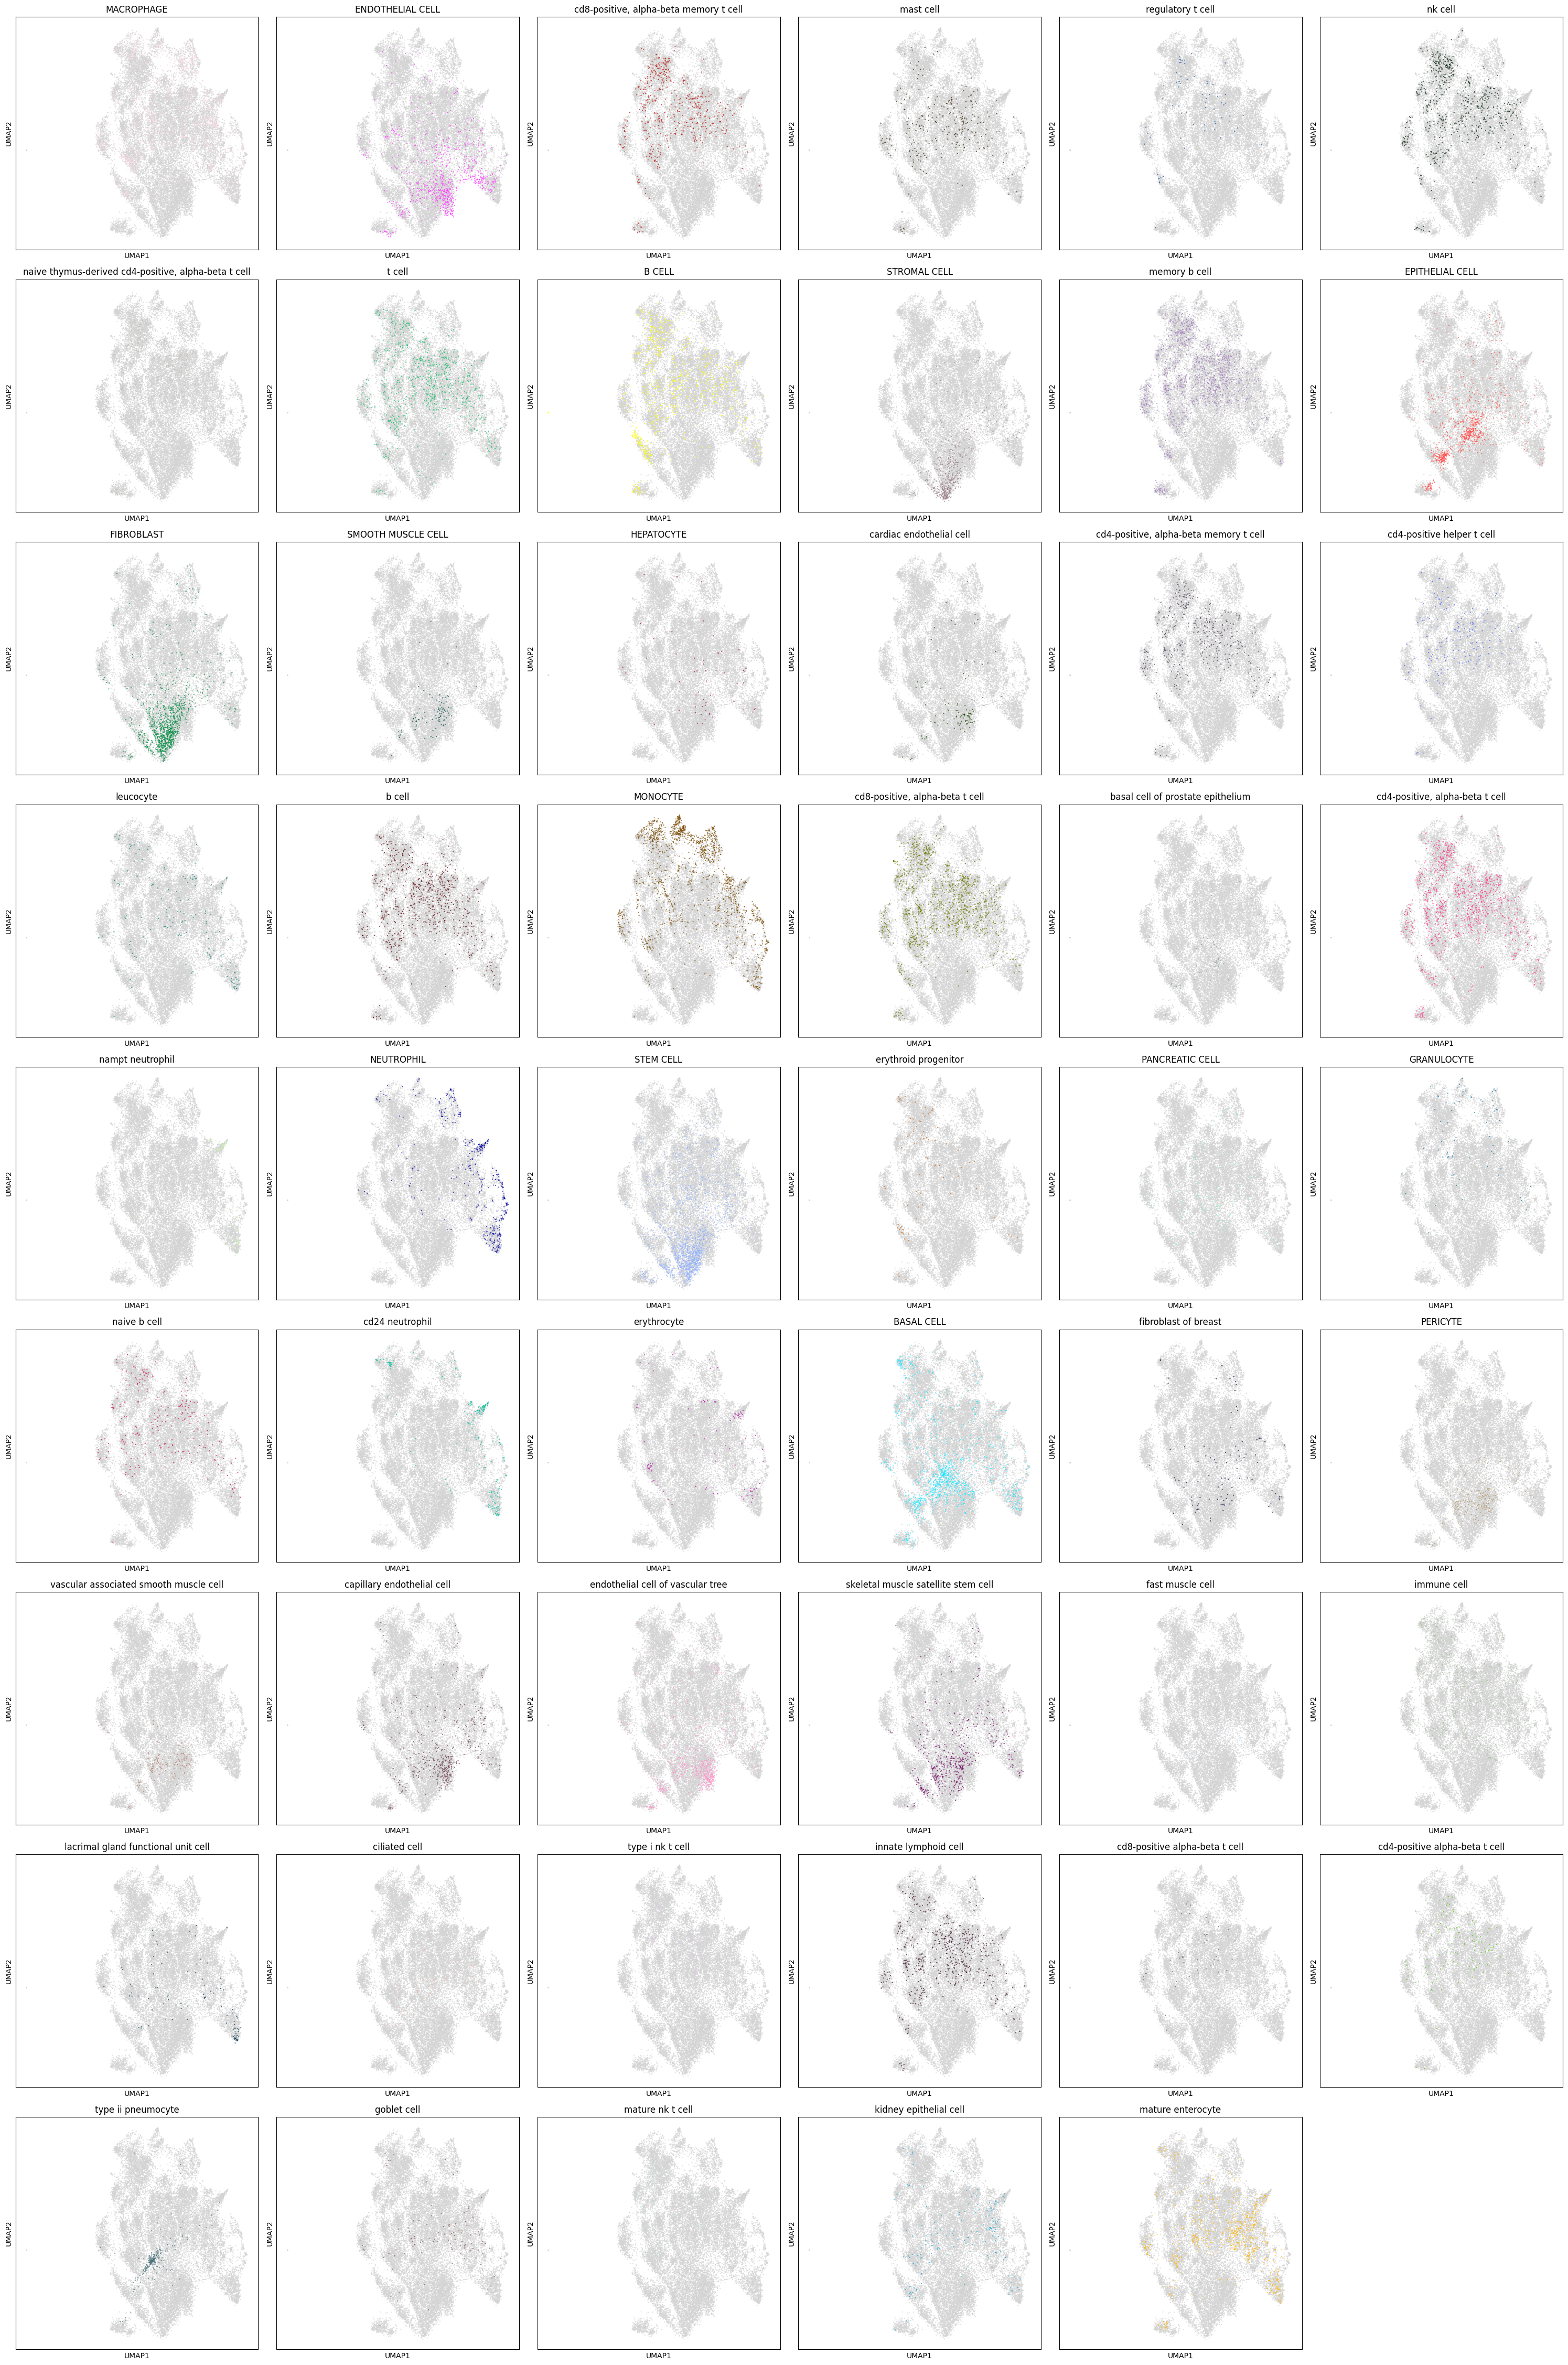

In [28]:
# Get the unique tissues in adata.obs['cell_ontology_class']
tissues = splice_adata.obs['cell_type_grouped'].unique()

# Set up grid dimensions: 6 rows, adjust columns to fit the number of tissues
n_tissues = len(tissues)
n_rows = 10  # Set to 6 rows
n_cols = int(np.ceil(n_tissues / n_rows))  # Calculate the number of columns needed

# Create a grid of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))  # Adjust figure size as needed
axes = axes.flatten()  # Flatten axes to easily loop through them

# Plot each tissue's UMAP in its subplot without legend
for i, tissue in enumerate(tissues):
    ax = axes[i]
    
    # Plot UMAP for the specific tissue on the corresponding subplot without the legend
    sc.pl.umap(splice_adata, color="cell_type_grouped", groups=[tissue], show=False, size=10, alpha=0.7, ax=ax, legend_loc="none")
    
    # Set title for each subplot with the tissue name
    ax.set_title(tissue)

# Turn off unused axes if there are any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout for better spacing
plt.tight_layout()

# Show the combined grid of plots
plt.show()

### Generate_initializations matrices for Phi and Psi

In [29]:
rho_hat = splice_adata.layers["junc_ratio"]

# Generate multiple initializations
psi_initializations, phi_initializations = wayp.generate_initializations(rho_hat, waypoints_dict, metacell_dicts, epsilon=0.001)

Finding 30 waypoints from the diffusion components!


30it [00:07,  3.97it/s]


Finding 50 waypoints from the diffusion components!


50it [00:12,  4.08it/s]


Finding 100 waypoints from the diffusion components!


100it [00:23,  4.18it/s]


In [30]:
# Loop through the waypoints_dict and corresponding initializations
for i, n_waypoints in enumerate(waypoints_dict.keys()):

    print(f"Adding waypoint based initializations to anndata for {n_waypoints} waypoints!")

    # Extract the corresponding psi and phi initializations
    psi = psi_initializations[i]
    phi = phi_initializations[i]

    # Convert psi and phi to torch tensors if needed
    psi = torch.tensor(psi)
    phi = torch.tensor(phi)

    # Convert to NumPy arrays if psi and phi are torch tensors (just in case)
    if isinstance(psi, torch.Tensor):
        psi = psi.cpu().numpy()  # Convert to NumPy array
    if isinstance(phi, torch.Tensor):
        phi = phi.cpu().numpy()  # Convert to NumPy array

    # Store psi in `adata.varm` and phi in `adata.obsm` with keys based on the number of waypoints
    splice_adata.varm[f'psi_init_{n_waypoints}_waypoints'] = psi  # Store psi with name 'psi_init_{n_waypoints}_waypoints'
    splice_adata.obsm[f'phi_init_{n_waypoints}_waypoints'] = phi  # Store phi with name 'phi_init_{n_waypoints}_waypoints'


Adding waypoint based initializations to anndata for 30 waypoints!
Adding waypoint based initializations to anndata for 50 waypoints!
Adding waypoint based initializations to anndata for 100 waypoints!


In [31]:
# Convert the 'junc_ratio' layer to a CSR matrix before saving
if isinstance(splice_adata.layers['junc_ratio'], coo_matrix):
    splice_adata.layers['junc_ratio'] = splice_adata.layers['junc_ratio'].tocsr()

### Save splice_adata Anndata object

In [32]:
# Original file path
original_path = input_file  # Input your original file path

# Extract the directory and filename
base_directory = os.path.dirname(original_path)
original_filename = os.path.basename(original_path)

# Get the current date and time as a string (format: YYYYMMDD_HHMMSS)
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

# Replace the date and timestamp part with "with_initializations" and append the new timestamp
filename_parts = original_filename.split('_')

new_filename = f"{'_'.join(filename_parts[:-2])}_WITH_GTF_with_initializations_{timestamp}.h5ad"

# Create the new full file path
new_file_path = os.path.join(base_directory, new_filename)

# Save the AnnData object with the new filename
splice_adata.write_h5ad(new_file_path, compression='gzip')

print(f"AnnData saved as {new_file_path}")

AnnData saved as /commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs/ATSE_Anndata_with_GTF_Object_WITH_GTF_with_initializations_20250109_161452.h5ad


### Save Gene Expression based Anndata object! 

In [34]:
from datetime import datetime

In [35]:
# Step 1: Get the current date in the desired format
current_date = datetime.now().strftime('%Y-%m-%d')

# Step 2: Format the file path with the current date
new_file_path = f"/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs/TabulaSapien_Anndata_GeneExpression_{current_date}.h5ad"

# Step 3: Save the anndata object with gzip compression
adata_reordered.write_h5ad(new_file_path, compression='gzip')

print(f"Gene expression Anndata object successfully saved to {new_file_path}")

Gene expression Anndata object successfully saved to /commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs/TabulaSapien_Anndata_GeneExpression_2025-01-09.h5ad
